# Core Concepts: Heterogeneous Activation Layers

In standard neural networks, all neurons within a single layer typically share the exact same activation function (e.g., a layer of 64 ReLU neurons).

HeteroSymNN introduces **Heterogeneous Activation Layers**: each neuron within a single layer can
run its own mathematical function, completely independent from its neighbors.

To see this in action, we'll build a single layer with 5 neurons — each one evaluating a
different activation function — and visualize them side by side.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from HeteroSymNN.Core.Nets import HeteroLinearNet
from HeteroSymNN.Backend import hardware as HW

## Defining the Heterogeneous Layer

We define the layer's activations using a list of tuples, where each tuple is `(math_string, constants_dict)`. 

Notice how we can seamlessly mix standard named functions like `"relu"` with custom symbolic math like `"cos(num)"` and `"num**2"`.

In [ ]:
nodes = [10, 5, 1]

# 5 neurons, 5 completely different functions!
mixed_layer_config = [
    ("relu", {}),
    ("sigmoid", {}),
    ("cos(num)", {}), 
    ("num / (1 + exp(-num))", {}), # Custom Swish implementation
    ("num**2", {})
]

output_config = [("num", {})]
detailed_activations = [mixed_layer_config, output_config]

print("Building Model with Heterogeneous Neurons...")
model = HeteroLinearNet(
    num_inputs=nodes[0],
    detailed_activations=detailed_activations,
    batch_size=4
)

if HW.GPU_ENABLED:
    model.set_gpu_id(0)
    model.set_backend("GPU_CUDA")
    model.to("device")
    print("Compiled mixed CUDA kernel.")
else:
    model.set_backend("CPU_JIT")
    print("Compiled mixed C++ kernel.")

Building Model with Heterogeneous Neurons...


c:\Users\dilos\Documents\GitHub\HeteroSymNN\HeteroSymNN\error_handlers.py:15: PerformanceWarning: Initiating engine migration to GPU_CUDA. This requires JIT recompilation and memory transfers.
  return func(*args, **kwargs)


Compiled mixed CUDA kernel.


## Visualizing Neuron Behavior

To isolate each neuron's output, we set the layer's weight matrix to the identity (diagonal of 1s,
zeros elsewhere). This routes each input exclusively to one neuron: Input 0 → Neuron 0, Input 1 → Neuron 1, and so on.

We then sweep a linear range through the layer and plot each neuron's response independently, revealing its distinct activation curve.


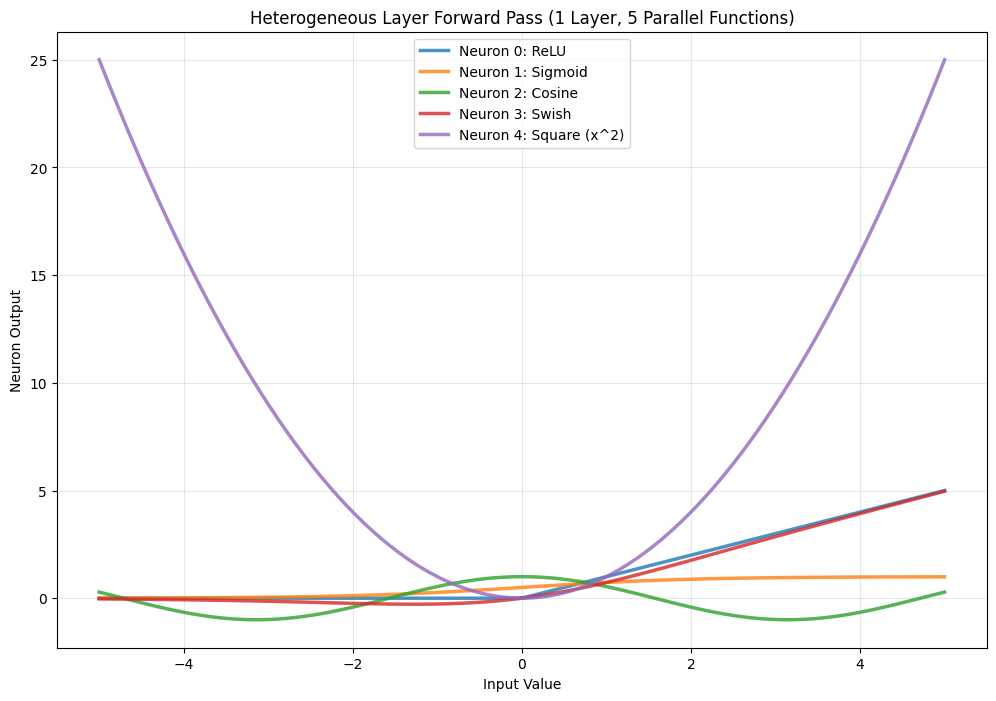

In [3]:
layer0 = model.layers[0]

# Force weights to be diagonal so Input[i] -> Neuron[i]
if HW.GPU_ENABLED:
    import cupy as cp
    layer0._weights = cp.zeros_like(layer0._weights)
    layer0._biases = cp.zeros_like(layer0._biases)
    for i in range(5):
        layer0._weights[i, i] = 1.0
else:
    layer0._weights = np.zeros_like(layer0._weights)
    layer0._biases = np.zeros_like(layer0._biases)
    for i in range(5):
        layer0._weights[i, i] = 1.0

# Generate a range of inputs from -5 to 5
x_vals = np.linspace(-5, 5, 100).astype(np.float32)
# We copy x_vals into 5 columns (padded to 10 since the layer expects 10 inputs)
test_input = np.zeros((100, 10), dtype=np.float32)
for i in range(5):
    test_input[:, i] = x_vals

# Forward pass through the heterogeneous layer
if layer0.computational_method == "GPU_CUDA":
    gpu_in = model.cast_arrays(test_input.T)
    gpu_out = layer0.forward(gpu_in)
    activations = model.asnumpy(gpu_out) 
else:
    out = layer0.forward(test_input.T)
    activations = out

# Plotting
plt.figure(figsize=(12, 8))
labels = ["Neuron 0: ReLU", "Neuron 1: Sigmoid", "Neuron 2: Cosine", "Neuron 3: Swish", "Neuron 4: Square (x^2)"]

for i in range(5):
    plt.plot(x_vals, activations[i, :], label=labels[i], linewidth=2.5, alpha=0.8)
    
plt.title("Heterogeneous Layer Forward Pass (1 Layer, 5 Parallel Functions)")
plt.xlabel("Input Value")
plt.ylabel("Neuron Output")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## What's Happening Under the Hood

The plot confirms that all 5 neurons in **a single layer** executed completely different
mathematical functions:
- Neuron 0: ReLU · Neuron 1: Sigmoid · Neuron 2: Cosine · Neuron 3: Swish · Neuron 4: Quadratic

Behind the scenes, HeteroSymNN's JIT compiler fused those 5 distinct mathematical strings into
a **single C++ or CUDA kernel**. There is no per-neuron dispatch overhead — the heterogeneous
layer runs with the same efficiency as a conventional, uniform-activation layer.
